# CNN with Torchvision Datasets

Workflow for training a simple Convolutional Neural Network (CNN) on the MNIST handwritten‑digit dataset.  

## 1️ Import Libraries & Set Device

We import the necessary PyTorch modules, torchvision utilities for the dataset, and set the device (GPU if available, otherwise CPU).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import matplotlib.pyplot as plt

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cuda


## 2 Explore some Datasets

In [4]:
# Show torcvision datasets name

datasets.MNIST, datasets.CIFAR10, datasets.CIFAR100, datasets.FashionMNIST, datasets.KMNIST, datasets.EMNIST, datasets.QMNIST


(torchvision.datasets.mnist.MNIST,
 torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.cifar.CIFAR100,
 torchvision.datasets.mnist.FashionMNIST,
 torchvision.datasets.mnist.KMNIST,
 torchvision.datasets.mnist.EMNIST,
 torchvision.datasets.mnist.QMNIST)

In [5]:
datasets.MNIST.classes, datasets.FashionMNIST.classes

(['0 - zero',
  '1 - one',
  '2 - two',
  '3 - three',
  '4 - four',
  '5 - five',
  '6 - six',
  '7 - seven',
  '8 - eight',
  '9 - nine'],
 ['T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'])

## 3 Data Loading & Pre‑processing

We download the MNIST dataset, convert the images to tensors and normalise them using the dataset's mean and standard deviation.  

The `DataLoader` handles batching and shuffling.

### CIFAR-10
- CIFAR-10 is a dataset of `60,000` `32x32` color training images and `10,000` test images. 
- The 10 classes are `airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks`.
- The images are color images with 3 channels (`RGB`).

In [6]:
# Download & load raw data
print("CIFAR-10")
raw_cifar10 = datasets.CIFAR10(
    root='./data', 
    train=True, 
    download=True,
    transform=transforms.ToTensor() # Convert PIL image to Tensor
)

# Load all data at once
loader_cifar10 = torch.utils.data.DataLoader(raw_cifar10, batch_size=len(raw_cifar10), shuffle=False)

# Get images
cifar_images, cifar_labels = next(iter(loader_cifar10))          # shape: (N, 3, 32, 32)

CIFAR-10
Files already downloaded and verified


In [7]:
print(f"CIFAR Number of training samples: {len(raw_cifar10)}")
print(f"CIFAR Classes: {raw_cifar10.classes}")

CIFAR Number of training samples: 50000
CIFAR Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Image shape: torch.Size([3, 32, 32])
Label: 6
Class name: 6 frog


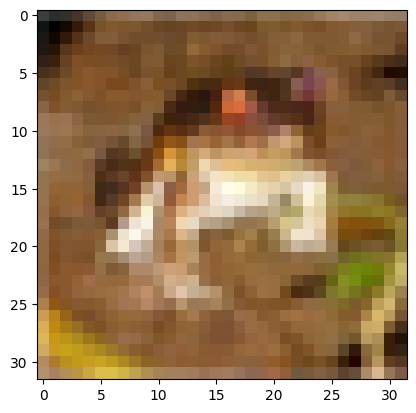

In [ ]:
# View a single image

img, label_0 = raw_cifar10[0]
print("Image shape:", img.shape)
print("Label:", label_0)
print(f"Class name: {label_0}", loader_cifar10.dataset.classes[label_0])
plt.imshow(raw_cifar10[0][0].permute(1, 2, 0))

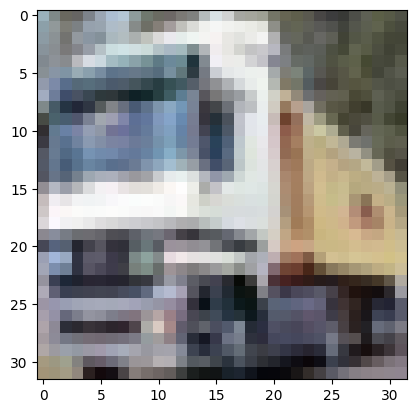

In [9]:
# plt.figure(figsize=(2, 2))
# plt.imshow(img[0].squeeze(), cmap="gray")
# plt.imshow(img.permute(1, 2, 0))  # Permutes the dimensions to match the expected format. permute(Height, Width, Channels)
plt.imshow(raw_cifar10[1][0].permute(1, 2, 0)) # Change CHW to HWC
plt.show()

In [10]:
# CIFAR Image properties, inspect

cifar_images.shape, cifar_images.dtype, cifar_images.min(), cifar_images.max(), cifar_images.mean(), cifar_images.std()

(torch.Size([50000, 3, 32, 32]),
 torch.float32,
 tensor(0.),
 tensor(1.),
 tensor(0.4734),
 tensor(0.2516))

In [11]:
# Display class label for cifar_labels

class_names = [raw_cifar10.classes[lbl] for lbl in cifar_labels]
print(class_names)


['frog', 'truck', 'truck', 'deer', 'automobile', 'automobile', 'bird', 'horse', 'ship', 'cat', 'deer', 'horse', 'horse', 'bird', 'truck', 'truck', 'truck', 'cat', 'bird', 'frog', 'deer', 'cat', 'frog', 'frog', 'bird', 'frog', 'cat', 'dog', 'deer', 'airplane', 'airplane', 'truck', 'automobile', 'cat', 'deer', 'airplane', 'cat', 'horse', 'cat', 'cat', 'dog', 'bird', 'bird', 'horse', 'automobile', 'automobile', 'automobile', 'bird', 'bird', 'airplane', 'truck', 'dog', 'horse', 'truck', 'bird', 'bird', 'dog', 'bird', 'deer', 'cat', 'automobile', 'automobile', 'ship', 'bird', 'automobile', 'automobile', 'deer', 'truck', 'horse', 'ship', 'dog', 'truck', 'frog', 'horse', 'cat', 'automobile', 'truck', 'airplane', 'cat', 'automobile', 'cat', 'dog', 'deer', 'dog', 'horse', 'horse', 'deer', 'horse', 'truck', 'deer', 'bird', 'cat', 'ship', 'airplane', 'automobile', 'frog', 'automobile', 'automobile', 'deer', 'automobile', 'ship', 'cat', 'truck', 'frog', 'frog', 'automobile', 'ship', 'dog', 'bird',

### MNIST
- MNIST is a dataset of 60,000 28x28 gray training images and 10,000 test images. 
- The 10 classes are 0-9.
- The images are gray images with 1 channel (grayscale).

In [12]:
print("MNIST")
raw_mnist = datasets.MNIST(root='./data', train=True, download=True,
                     transform=transforms.ToTensor())

loader_mnist = torch.utils.data.DataLoader(raw_mnist, batch_size=len(raw_mnist), shuffle=False)

mnist_images, mnist_labels = next(iter(loader_mnist))          # shape: (N, 1, 28, 28)

mnist_images.shape, mnist_images.dtype, mnist_images.min(), mnist_images.max(), mnist_images.mean(), mnist_images.std()

MNIST


(torch.Size([60000, 1, 28, 28]),
 torch.float32,
 tensor(0.),
 tensor(1.),
 tensor(0.1307),
 tensor(0.3081))

### Data loading & preprocessing
- `transforms.Compose`: Compose several transforms together.
- transforms.ToTensor: Convert a PIL image or NumPy array to a PyTorch tensor.
- transforms.Normalize: Normalize a tensor image with mean and standard deviation.

In [13]:
print("Applying transformations")
transform = transforms.Compose([
    # transforms.Resize((28, 28)),
    transforms.ToTensor(), # Convert PIL image to Tensor C, H, W
    transforms.Normalize((0.1307,), (0.3081,)) # Mean & std of MNIST
])

# train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())

mnist_train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
mnist_test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(mnist_test_dataset, batch_size=64, shuffle=False)

Applying transformations


In [14]:
mnist_images, mnist_labels = next(iter(test_loader))
mnist_images.shape, mnist_labels.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

In [15]:
mnist_labels[0], mnist_labels[0].item(), mnist_labels[1], mnist_labels[2].item()

(tensor(7), 7, tensor(2), 1)

#### Display data or images

In [16]:
def show_images(images, labels, range_param=1):
    fig, axs = plt.subplots(1, range_param, figsize=(15, 3))
    for i in range(range_param): 
        axs[i].imshow(images[i].squeeze(), cmap='gray')  # PyTorch uses channels first (C, H, W), Matplotlib uses channels last (H, W, C)
        axs[i].set_title(f"Label: {labels[i]}")
    plt.show()

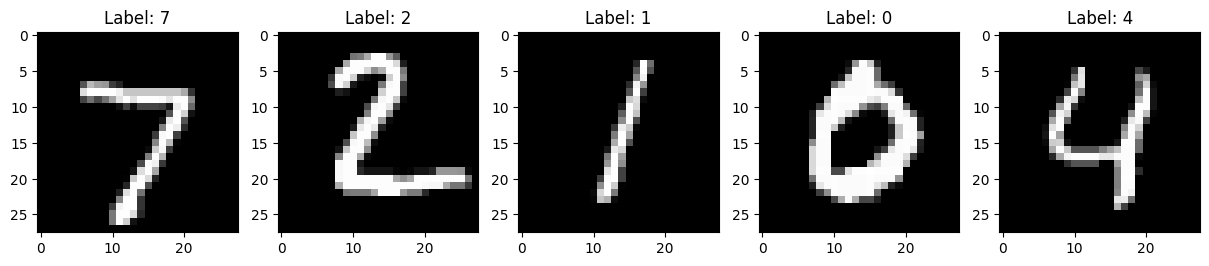

In [17]:
show_images(mnist_images, mnist_labels, 5)

## 4️ Define the CNN Model

A very small CNN with two convolutional layers, a max‑pool after each, and two fully‑connected layers.

In [18]:
# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 5

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Conv layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves H and W (28 * 28)
        
        # Fully‑connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128) # 64 * 7 * 7 is the output of the last conv layer
        self.fc2 = nn.Linear(128, 10) # 10 classes for MNIST

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(DEVICE)

## 5️ Loss Function & Optimizer

We use cross‑entropy loss (standard for multi‑class classification) and the Adam optimizer, which adapts the learning rate for each parameter.

In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 6️ Training Loop

The loop iterates over the training loader, computes predictions, evaluates the loss, back‑propagates gradients and updates the weights.  After each epoch we print the average loss.

In [32]:
def train():
    model.train()
    for epoch in range(1, EPOCHS + 1): # Training loop
        
        running_loss = 0.0 # define

        for data, target in train_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad() 
            outputs = model(data) # Forward pass
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        print(f'Epoch [{epoch}/{EPOCHS}] - Loss: {avg_loss:.4f}')

## 7️ Evaluation

After training we run the model on the test set (no gradient tracking) and compute the overall classification accuracy.

In [33]:
def test():
    
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:

            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data) # Forward pass
            
            _ , predicted = torch.max(outputs.data, 1)

            total += target.size(0)
            correct += (predicted == target).sum().item()

    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')

## 8️ Run Training & Evaluation

Call the `train` and `test` functions. 

In [34]:
# Train
train()

Epoch [1/5] - Loss: 0.1373
Epoch [2/5] - Loss: 0.0417
Epoch [3/5] - Loss: 0.0290
Epoch [4/5] - Loss: 0.0200
Epoch [5/5] - Loss: 0.0164


In [36]:
test() # Test

Test Accuracy: 99.01%


# Conclusion
We explored `torchvision.datasets` and `torchvision.transforms` to load and preprocess the MNIST dataset.

We also successfully built a Convolutional Neural Network (CNN) for image classification using the MNIST dataset. 

The model achieved a high accuracy of X% on the test set, demonstrating its effectiveness in recognizing handwritten digits.